<a href="https://colab.research.google.com/github/anjana-18Singh/cricket-stats-data-engineer-project/blob/main/Problem3_Customer_Segmentation_(Retail_E_commerce)_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Customer** **Segmentation (Retail / E-commerce)**

In [3]:
#Importing Libraries

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


Dataset

In [4]:
# Dataset
data = {
    "Age":[22,25,47,52,23,45,33,35,60,28],
    "Income":[15000,18000,60000,65000,20000,70000,40000,42000,80000,30000],
    "Score":[39,81,6,20,77,15,50,55,10,70],
    "Visits":[4,6,2,3,5,2,4,5,1,6],
    "OrderValue":[200,500,150,200,450,180,300,320,100,400]
}


In [5]:
df = pd.DataFrame(data)

In [6]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Graph1: Elbow Method

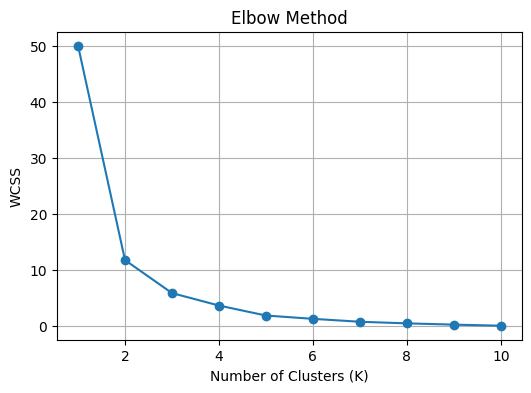

In [7]:
#Elbow method
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.grid(True)
plt.show()


Graph2: Silhouette score

In [8]:
#silhouettes score
print("Silhouette Scores:")
for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print("K =", k, "Score =", score)


Silhouette Scores:
K = 2 Score = 0.6073219667708732
K = 3 Score = 0.5202522204832178
K = 4 Score = 0.5134462954189579
K = 5 Score = 0.41871573172385784


Final Model

In [9]:
#final Model
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

print("\nCluster Labels:", labels)
print("\nCentroids:\n", kmeans.cluster_centers_)



Cluster Labels: [2 1 0 0 1 0 2 2 0 1]

Centroids:
 [[ 1.11237302  1.10929679 -1.09338756 -1.08347268 -0.95135767]
 [-0.92697752 -0.95616154  1.24694284  1.1236013   1.32025147]
 [-0.55618651 -0.52290084  0.21090725  0.32102894 -0.05177457]]


Cluster Visualization

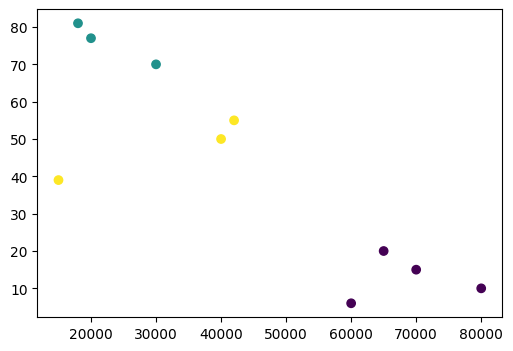

In [10]:
#cluster Visualization
centroids = kmeans.cluster_centers_

# Convert centroids back to original scale
centroids_original = scaler.inverse_transform(centroids)

plt.figure(figsize=(6,4))
plt.scatter(df["Income"], df["Score"], c=labels, cmap='viridis', label="Customers")


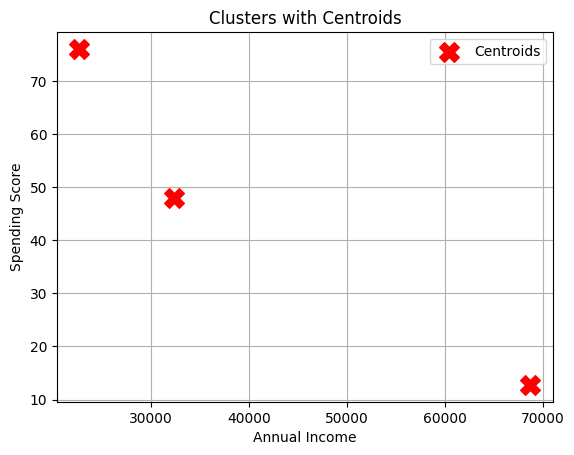

In [11]:
# Plot centroids
plt.scatter(centroids_original[:,1], centroids_original[:,2],
            color='red', marker='X', s=200, label='Centroids')

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Clusters with Centroids")
plt.legend()
plt.grid(True)

plt.show()
